### O gym 0.26 (mais atual) tem parametros diferentes comparado ao do instrutor (next_state, reward, done, info = streets.step(action)), por isso decidi fazer um downgrade para a versao dele (0.12.5) e deu certo!

In [2]:
import gym
import random

In [3]:
random.seed(33)
# gera os mesmos numeros 

In [ ]:
streets = gym.make("Taxi-v2").env
# mega o modelo de jogo com regras Taxi
streets.reset()


+---------+
|R: | : :G|
| : : : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+

None


In [ ]:
initial_state=streets.encode(2,3,2,0)
streets.s = initial_state


+---------+
|R: | : :G|
| : : : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+

None


In [6]:
streets.P[initial_state]

{0: [(1.0, 368, -1, False)],
 1: [(1.0, 168, -1, False)],
 2: [(1.0, 288, -1, False)],
 3: [(1.0, 248, -1, False)],
 4: [(1.0, 268, -10, False)],
 5: [(1.0, 268, -10, False)]}

In [7]:
import numpy as np

q_table = np.zeros([streets.observation_space.n, streets.action_space.n])
# tabela de que representa todos os estado e acoes possiveis no jogo
learning_rate = 0.1
#velocidade de aprendizado
discount_factor = 0.6
# fator de desconto
exploration = 0.1
epochs = 10000
# quantas vezes sera feito o treino 

#conta quantos passos foram dados em cada epoca
steps_ep = []

for taxi_run in range(epochs):
    state = streets.reset()
    #estado inicial
    done = False
    steps=0
    
    while not done:
        random_value = random.uniform(0,1)
        # sorteia um numero entre 0 e 1 e depois verifica se esse numero for menor que o fato de expçoração
        if(random_value < exploration):
            action = streets.action_space.sample()
            #explora uma açao nova aleatoria
        else:
            action = np.argmax(q_table[state])
            #pega uma  acao da tabela 
        
        next_state, reward, done, info = streets.step(action)
        # retorna o estado, a recompensa, se a entrega foi feita
        
        prev_q = q_table[state, action]
        # pega o valor q atual na tabela
        next_max_q = np.max(q_table[next_state])
        # pega o maior valor das acoes possiveis a partir do proximo estado
        new_q =(1 - learning_rate) * prev_q +learning_rate * (reward +discount_factor * next_max_q)
        # pega o que ja sabia antes e o que aprendeu
        q_table[state,action] = new_q
        # salva o novo valor na tabela
        
        state = next_state
        # pula para o proximo estado
        steps+=1
        # contador de passos
    steps_ep.append(steps)
    #adiciona na lista de passos por epoca

In [8]:
q_table[initial_state]

array([-2.40253896, -2.41041287, -2.3986095 , -2.3639511 , -8.65622891,
       -5.79711272])

In [10]:
from IPython.display import clear_output
from time import sleep

for tripnum in range(1,11):
    state= streets.reset()
    
    done = False
    
    while not done:
        action = np.argmax(q_table[state])
        next_state, reward, done, info = streets.step(action)
        clear_output(wait=True)
        print("Trip number " + str(tripnum))
        print(streets.render(mode ='ansi'))
        sleep(.5)
        state = next_state
    sleep(2)
# faz 10 viagens de taxi, pega o passageiro e entrega no ponto

Trip number 6
+---------+
|R: | : :G|
| : : : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)



KeyboardInterrupt: 

In [11]:
steps_ep
# lista de passos por epoca

[1063,
 1259,
 579,
 670,
 526,
 812,
 202,
 1420,
 342,
 1776,
 491,
 997,
 524,
 762,
 1051,
 701,
 220,
 664,
 212,
 897,
 564,
 281,
 456,
 621,
 449,
 103,
 499,
 646,
 313,
 330,
 379,
 290,
 509,
 515,
 115,
 574,
 368,
 291,
 546,
 349,
 878,
 671,
 499,
 187,
 334,
 740,
 203,
 239,
 427,
 297,
 115,
 435,
 291,
 196,
 419,
 279,
 906,
 309,
 276,
 289,
 232,
 300,
 260,
 378,
 272,
 150,
 406,
 130,
 171,
 526,
 213,
 150,
 262,
 121,
 271,
 374,
 291,
 138,
 359,
 434,
 144,
 191,
 329,
 160,
 189,
 113,
 191,
 504,
 403,
 341,
 252,
 276,
 101,
 172,
 147,
 13,
 211,
 11,
 54,
 217,
 303,
 340,
 287,
 253,
 264,
 340,
 241,
 245,
 90,
 215,
 156,
 402,
 332,
 131,
 371,
 157,
 39,
 50,
 172,
 303,
 343,
 297,
 108,
 319,
 84,
 108,
 232,
 351,
 226,
 219,
 189,
 305,
 28,
 161,
 253,
 187,
 265,
 170,
 82,
 361,
 77,
 298,
 118,
 52,
 44,
 133,
 276,
 179,
 182,
 141,
 219,
 182,
 61,
 411,
 144,
 36,
 69,
 161,
 219,
 249,
 263,
 12,
 268,
 203,
 104,
 163,
 237,
 59,
 174

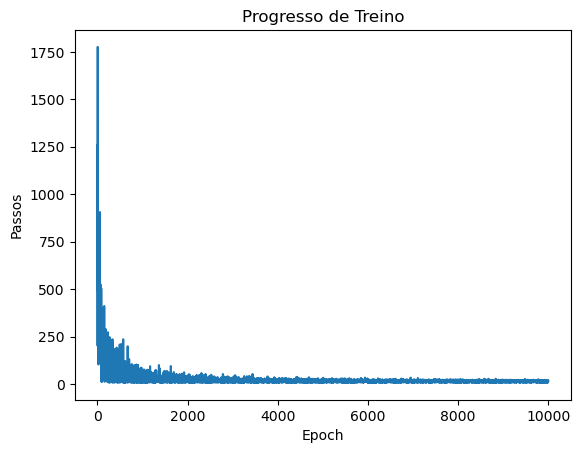

In [12]:
import matplotlib.pyplot as plt

plt.plot(steps_ep)
plt.xlabel('Epoch')
plt.ylabel('Passos')
plt.title('Progresso de Treino')
plt.savefig('progresso_treino.png', dpi=300, bbox_inches='tight')
# grafico que mostra o quando o modelo realmente aprendeu a cada passo

plt.show()